In [1]:
import pandas as pd
import numpy as np
import ast
import os
import glob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# ==========================================
# 0. 설정
# ==========================================
folder_path = '/content/drive/MyDrive/텍마팀플/project/리뷰DB_tokenized'
output_excel_name = '/content/drive/MyDrive/텍마팀플/project/도서별_정서DNA_MBTI결과_최종.xlsx'
n_topics = 6

# 불용어 리스트
my_stop_words = [
    '책', '도서', '저자', '작가', '구매', '주문', '배송', '서평', '리뷰', '발송', '구입', '판매', 'yes24', '예스24', '포장',
    '사람', '생각', '내용', '읽히', '감사', '만들', '부분', '정도', '하나', '이번', '자신', '지금',
    '때문', '관련', '그것', '무엇', '어디','소설','니오',
    '정말', '너무', '많이', '진짜', '아주', '매우', '가장', '아직','제일', '항상', '역시', '다시', '계속',
    '읽기', '읽고', '읽다', '보다', '보니', '보고', '재밌', '재미있', '보이', '해서', '하게', '하다', '합니다', '입니다',
    '있는', '없는','대하','위하','사람','책','인생','아이',
    '추천', '강추'
]



# ==========================================
# 1. 데이터 통합
# ==========================================
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
combined_data = []

for filename in all_files:
    try:
        df_temp = pd.read_csv(filename)
        if 'sentiment_tokens' not in df_temp.columns: continue

        # 도서명 식별
        title = df_temp['title_norm'].iloc[0] if 'title_norm' in df_temp.columns else os.path.basename(filename).replace('.csv', '')

        temp_subset = df_temp[['sentiment_tokens']].copy()
        temp_subset['book_title'] = title
        combined_data.append(temp_subset)
    except:
        continue

big_df = pd.concat(combined_data, ignore_index=True)
big_df['sentiment_tokens'] = big_df['sentiment_tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
big_df = big_df[big_df['sentiment_tokens'].map(len) > 0].reset_index(drop=True)

print(f"데이터 통합 완료 (총 {len(big_df)}개 리뷰)")


# ==========================================
# 2. 통합 토픽 모델링 (파라미터 튜닝)
# ==========================================

text_data = [" ".join(t) for t in big_df['sentiment_tokens']]

# max_df를 0.5로 낮춤 (전체 책의 50% 이상에 등장하는 단어는 삭제)
vectorizer = CountVectorizer(
    max_df=0.5,           # 너무 흔한 단어(상위 50% 등장) 무시 -> 변별력 상승
    min_df=3,             # 너무 희귀한 단어(3번 미만 등장) 무시 -> 오타 제거 효과
    stop_words=my_stop_words # 위에서 정의한 불용어 사전 적용
)

dtm = vectorizer.fit_transform(text_data)

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

# 토픽 이름 짓기
feature_names = vectorizer.get_feature_names_out()
topic_dict = {}

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-4:-1]
    top_words = [feature_names[i] for i in top_indices]
    topic_label = f"T{topic_idx+1}_" + "_".join(top_words)
    topic_dict[topic_idx] = topic_label

doc_topic_dist = lda.transform(dtm)
topic_cols = [topic_dict[i] for i in range(n_topics)]
topic_df = pd.DataFrame(doc_topic_dist, columns=topic_cols)
big_df = pd.concat([big_df, topic_df], axis=1)
book_scores = big_df.groupby('book_title')[topic_cols].mean()
# ==========================================
# 3. [시트 1] 도서별 상세 보기
# ==========================================
sheet1_rows = []
for title, row in book_scores.iterrows():
    sorted_series = row.sort_values(ascending=False)
    result_row = {
        '도서명': title,
        '1순위_정서': sorted_series.index[0],
        '1순위_비중': round(sorted_series.iloc[0] * 100, 1),
        '2순위_정서': sorted_series.index[1],
        '2순위_비중': round(sorted_series.iloc[1] * 100, 1),
    }
    for t_name in topic_cols:
        result_row[t_name] = round(row[t_name] * 100, 1)
    sheet1_rows.append(result_row)

df_sheet1 = pd.DataFrame(sheet1_rows)


# ==========================================
# 4. [시트 2] 전체 통계 요약
# ==========================================
# 1. 평균 비중 계산
global_means = book_scores[topic_cols].mean().sort_values(ascending=False)

# 2. 해당 토픽이 1순위인 책의 '개수' 카운트
count_series = df_sheet1['1순위_정서'].value_counts()

sheet2_rows = []
rank = 1
for topic_name, score in global_means.items():
    # 개수 가져오기 (없으면 0)
    count_val = count_series.get(topic_name, 0)

    sheet2_rows.append({
        '순위': rank,
        '토픽명(Key Emotion)': topic_name,
        '전체_평균_비중(%)': round(score * 100, 1),
        '대표_도서_수(권)': count_val,
        '설명': f"전체 {len(df_sheet1)}권 중 {count_val}권이 이 정서를 가장 강하게 띰"
    })
    rank += 1

df_sheet2 = pd.DataFrame(sheet2_rows)


# ==========================================
# 5. 엑셀 파일 생성
# ==========================================
with pd.ExcelWriter(output_excel_name) as writer:
    df_sheet1.to_excel(writer, sheet_name='1_도서별_토픽비중', index=False)
    df_sheet2.to_excel(writer, sheet_name='2_토픽별_통계요약', index=False)

# 시트 2 미리보기
print("\n[시트 2: 전체 통계 요약]")
print(df_sheet2[['순위', '토픽명(Key Emotion)', '전체_평균_비중(%)', '대표_도서_수(권)']])

데이터 통합 완료 (총 173957개 리뷰)

[시트 2: 전체 통계 요약]
   순위 토픽명(Key Emotion)  전체_평균_비중(%)  대표_도서_수(권)
0   1      T2_기대_투자_주식         18.2         109
1   2      T3_도움_마음_공부         16.8          71
2   3      T4_마음_선물_최고         16.6          98
3   4     T5_좋아하_나오_기대         16.3          72
4   5      T6_느끼_유익_인간         16.1          48
5   6      T1_흥미_필요_편하         15.9          62


In [ ]:
# 1. 폰트 설치 및 캐시 삭제
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("✅ 설치가 완료되었습니다.")
print("❗ 중요: 이제 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 클릭하세요.")
print("❗ 재시작 후에는 이 코드를 다시 실행하지 마세요.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

✅ 한글 폰트 설정이 완료되었습니다. 이제 그래프 코드를 다시 실행해보세요!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

✅ 한글 폰트 설정 완료 (차트 깨짐 방지)
📂 데이터 로드 완료: 총 460권의 도서 정보가 있습니다.

🗺️ [분석 1] 도서관 정서 지도 (Emotional Map)

📊 [정서별 도서 점유율 현황]
 - T2_기대_투자_주식: 109권 (23.7%)
 - T4_마음_선물_최고: 98권 (21.3%)
 - T5_좋아하_나오_기대: 72권 (15.7%)
 - T3_도움_마음_공부: 71권 (15.4%)
 - T1_흥미_필요_편하: 62권 (13.5%)
 - T6_느끼_유익_인간: 48권 (10.4%)


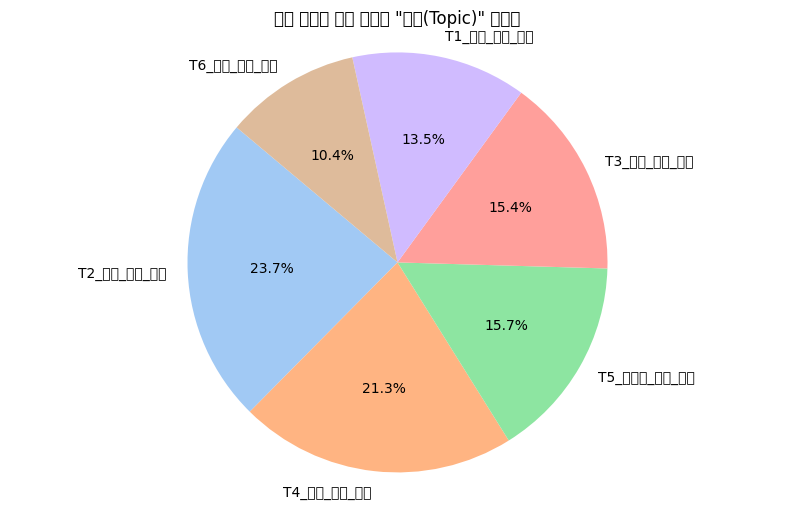


💡 [Insight]
우리 도서관은 현재 'T2_기대_투자_주식' 정서의 책이 23.7%로 가장 많습니다.
반면 'T6_느끼_유익_인간' 관련 도서는 10.4%에 불과하여, 해당 감정을 찾는 독자를 위한 큐레이션 보강이 필요할 수 있습니다.

장르 초월 유사 도서 추천 (DNA 매칭)
ℹ️ 분석에 사용된 토픽 DNA 컬럼: 6개

기준 도서: <강방천의관점>
   ㄴ 주된 정서: T2_기대_투자_주식 (43.2%)

[AI 추천] 정서적 결(Mood)이 비슷한 도서 TOP 3:
   1. <세븐테크> (유사도: 99.9%)
      ㄴ 핵심 정서: T2_기대_투자_주식
   2. <돈의시나리오> (유사도: 99.8%)
      ㄴ 핵심 정서: T2_기대_투자_주식
   3. <코로나사피엔스> (유사도: 99.6%)
      ㄴ 핵심 정서: T2_기대_투자_주식


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("✅ 한글 폰트 설정이 완료되었습니다. 이제 그래프 코드를 다시 실행해보세요!")

# ==========================================
# 0. 한글 폰트 설정 (Colab용)
# ==========================================
# 차트에서 한글이 깨지지 않도록 설정합니다.
import matplotlib.font_manager as fm
!apt-get -qq -y install fonts-nanum > /dev/null
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=10)
plt.rc('font', family='NanumBarunGothic')
print("✅ 한글 폰트 설정 완료 (차트 깨짐 방지)")


# 분석 결과 엑셀 파일 경로
file_path = '/content/drive/MyDrive/텍마팀플/project/도서별_정서DNA_MBTI결과_최종.xlsx'

df = pd.read_excel(file_path)
print(f"📂 데이터 로드 완료: 총 {len(df)}권의 도서 정보가 있습니다.")

print("\n" + "="*50)
print("🗺️ [분석 1] 도서관 정서 지도 (Emotional Map)")
print("="*50)

# 1순위 정서(Topic)별 도서 개수 세기
topic_counts = df['1순위_정서'].value_counts()
total_books = len(df)

print("\n📊 [정서별 도서 점유율 현황]")
for topic, count in topic_counts.items():
    percent = (count / total_books) * 100
    print(f" - {topic}: {count}권 ({percent:.1f}%)")

# --- 시각화 (파이 차트) ---
plt.figure(figsize=(10, 6))
colors = sns.color_palette('pastel')[0:len(topic_counts)]
plt.pie(topic_counts, labels=topic_counts.index, autopct='%.1f%%', startangle=140, colors=colors)
plt.title('우리 도서관 보유 도서의 "정서(Topic)" 분포도')
plt.axis('equal')  # 원형 유지
plt.show()

# --- 인사이트 자동 생성 ---
top_topic = topic_counts.index[0]
top_percent = (topic_counts.iloc[0] / total_books) * 100
min_topic = topic_counts.index[-1]
min_percent = (topic_counts.iloc[-1] / total_books) * 100

print(f"\n💡 [Insight]")
print(f"우리 도서관은 현재 '{top_topic}' 정서의 책이 {top_percent:.1f}%로 가장 많습니다.")
print(f"반면 '{min_topic}' 관련 도서는 {min_percent:.1f}%에 불과하여, 해당 감정을 찾는 독자를 위한 큐레이션 보강이 필요할 수 있습니다.")


# "장르를 뛰어넘는" 유사 도서 발견 (Cross-Genre)
print("\n" + "="*50)
print("장르 초월 유사 도서 추천 (DNA 매칭)")
print("="*50)

# 1. 분석에 사용할 토픽 컬럼들만 추출
topic_cols = [col for col in df.columns if col.startswith('T') and '_' in col]
print(f"ℹ️ 분석에 사용된 토픽 DNA 컬럼: {len(topic_cols)}개")

# 2. 코사인 유사도 계산
# 책들의 '정서 벡터' 사이의 각도를 계산하여 유사도(0~1)를 구함
similarity_matrix = cosine_similarity(df[topic_cols])

# 3. 추천 함수 정의
def recommend_similar_books(book_title, top_n=3):
    if book_title not in df['도서명'].values:
        return f"'{book_title}' 책을 데이터에서 찾을 수 없습니다."

    book_idx = df[df['도서명'] == book_title].index[0]

    sim_scores = list(enumerate(similarity_matrix[book_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)


    top_books = sim_scores[1 : top_n+1]

    print(f"\n기준 도서: <{book_title}>")
    print(f"   ㄴ 주된 정서: {df.iloc[book_idx]['1순위_정서']} ({df.iloc[book_idx]['1순위_비중']}%)")
    print(f"\n[AI 추천] 정서적 결(Mood)이 비슷한 도서 TOP {top_n}:")

    for i, (idx, score) in enumerate(top_books):
        rec_title = df.iloc[idx]['도서명']
        rec_topic = df.iloc[idx]['1순위_정서']
        print(f"   {i+1}. <{rec_title}> (유사도: {score*100:.1f}%)")
        print(f"      ㄴ 핵심 정서: {rec_topic}")

# --- 🚀 실제 테스트 (예시) ---
# 엑셀 파일에 실제로 존재하는 책 제목을 아래에 입력해야 작동합니다.
# 데이터가 준비되면 아래 변수명을 실제 책 제목으로 바꿔서 실행해보세요.

# 예시: 데이터의 첫 번째 책을 기준으로 테스트
sample_book = df['도서명'].iloc[27]
recommend_similar_books(sample_book, top_n=3)

# 특정 책을 검색하고 싶으면 아래 주석을 풀고 입력하세요
# recommend_similar_books("구의 증명", top_n=3)